In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

import tribus
from visualization import heatmap_for_median_expression, marker_expression, z_score

# Read in data

In [5]:
# read in your dataset
import os
path = "C:/Users/schromec/Desktop/tribus/data/"
output_path = "C:/Users/schromec/Desktop/tribus/data/output"
os.makedirs('{}'.format(output_path), exist_ok=True)

sample_name = "z45_2_cell"
sample_data = pd.read_csv('{}/{}.csv'.format(path, sample_name),low_memory=False)
print("Data dimension is {}".format(np.shape(sample_data)))
sample_data.columns

Data dimension is (11683, 36)


Index(['Unnamed: 0', 'CD45', 'HMGB1', 'CD31', 'MHCll', 'CD4', 'CD3', 'CD35',
       'Lyve-1', 'TUBB3', 'PDL-1', 'CD11c', 'FoxP3', 'CD8', 'CD11b', 'aSMA',
       'PD-1', 'B220', 'CD206', 'CD138', 'IgD', 'CD103', 'SIRPa', 'CD86',
       'IgA', 'ERTR7', 'ClvCasp3', 'Z', 'Y', 'X', 'Ext_Z', 'Ext_Y', 'Ext_Z.1',
       'gidx', 'blk', 'nidx'],
      dtype='object')

In [6]:
cols = ['CD45', 'HMGB1', 'CD31', 'MHCll', 'CD4', 'CD3', 'CD35',
       'Lyve-1', 'TUBB3', 'PDL-1', 'CD11c', 'FoxP3', 'CD8', 'CD11b', 'aSMA',
       'PD-1', 'B220', 'CD206', 'CD138', 'IgD', 'CD103', 'SIRPa', 'CD86',
       'IgA', 'ERTR7', 'ClvCasp3']
Q = sample_data[cols].quantile(0.999)
sample_data = sample_data[~((sample_data[cols] > Q)).any(axis=1)]
print("Removing the outliers. Current data dimension is {}".format(np.shape(sample_data)))
sample_data[cols].describe()

Removing the outliers. Current data dimension is (11430, 36)


,CD45,HMGB1,CD31,MHCll,CD4,CD3,CD35,Lyve-1,TUBB3,PDL-1,...,B220,CD206,CD138,IgD,CD103,SIRPa,CD86,IgA,ERTR7,ClvCasp3
count,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,...,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000
mean,270.416835,786.511342,80.871651,110.412870,185.867850,165.038585,22.686316,51.388581,30.825976,76.209983,...,488.109201,16.680394,36.829155,393.806243,73.515475,69.754642,73.610503,6.820200,24.132449,65.032088
std,127.841285,392.543656,52.949647,85.579597,146.918525,124.196478,14.747816,62.120853,14.352393,42.706557,...,308.211280,29.446944,27.019831,197.993694,80.753825,37.558778,40.034175,4.387012,31.100153,50.843141
min,8.510211,0.654231,0.762986,0.000804,0.007324,0.000000,0.178092,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.064758,2.313309,0.000000,0.000000,0.187966
25%,192.562934,548.298515,49.220077,53.852856,85.342723,77.892335,13.358257,25.557918,22.067254,50.268887,...,303.692902,5.160137,22.233453,276.406229,26.841166,43.825182,45.953581,4.127433,6.528055,35.831811
50%,248.427413,644.589892,59.516697,84.222008,140.783196,130.693649,17.448585,31.938924,26.497232,61.413544,...,398.664979,7.981790,28.075709,363.544420,47.486937,60.794196,59.878311,5.534240,13.145344,45.997295
75%,318.231746,875.937183,97.614089,145.744373,246.262214,215.017541,27.730472,54.234728,34.036947,87.521190,...,575.145715,15.380028,42.099779,459.776599,85.867349,85.714410,93.437622,8.409569,26.777062,75.961622
max,954.120548,2559.177570,425.647681,739.692933,1250.463007,1118.707631,129.263240,806.964294,88.674427,359.401944,...,2622.938456,464.659068,419.298151,1396.559516,828.596725,285.779063,319.210426,82.688357,265.015747,593.470160


<Figure size 2000x1800 with 0 Axes>

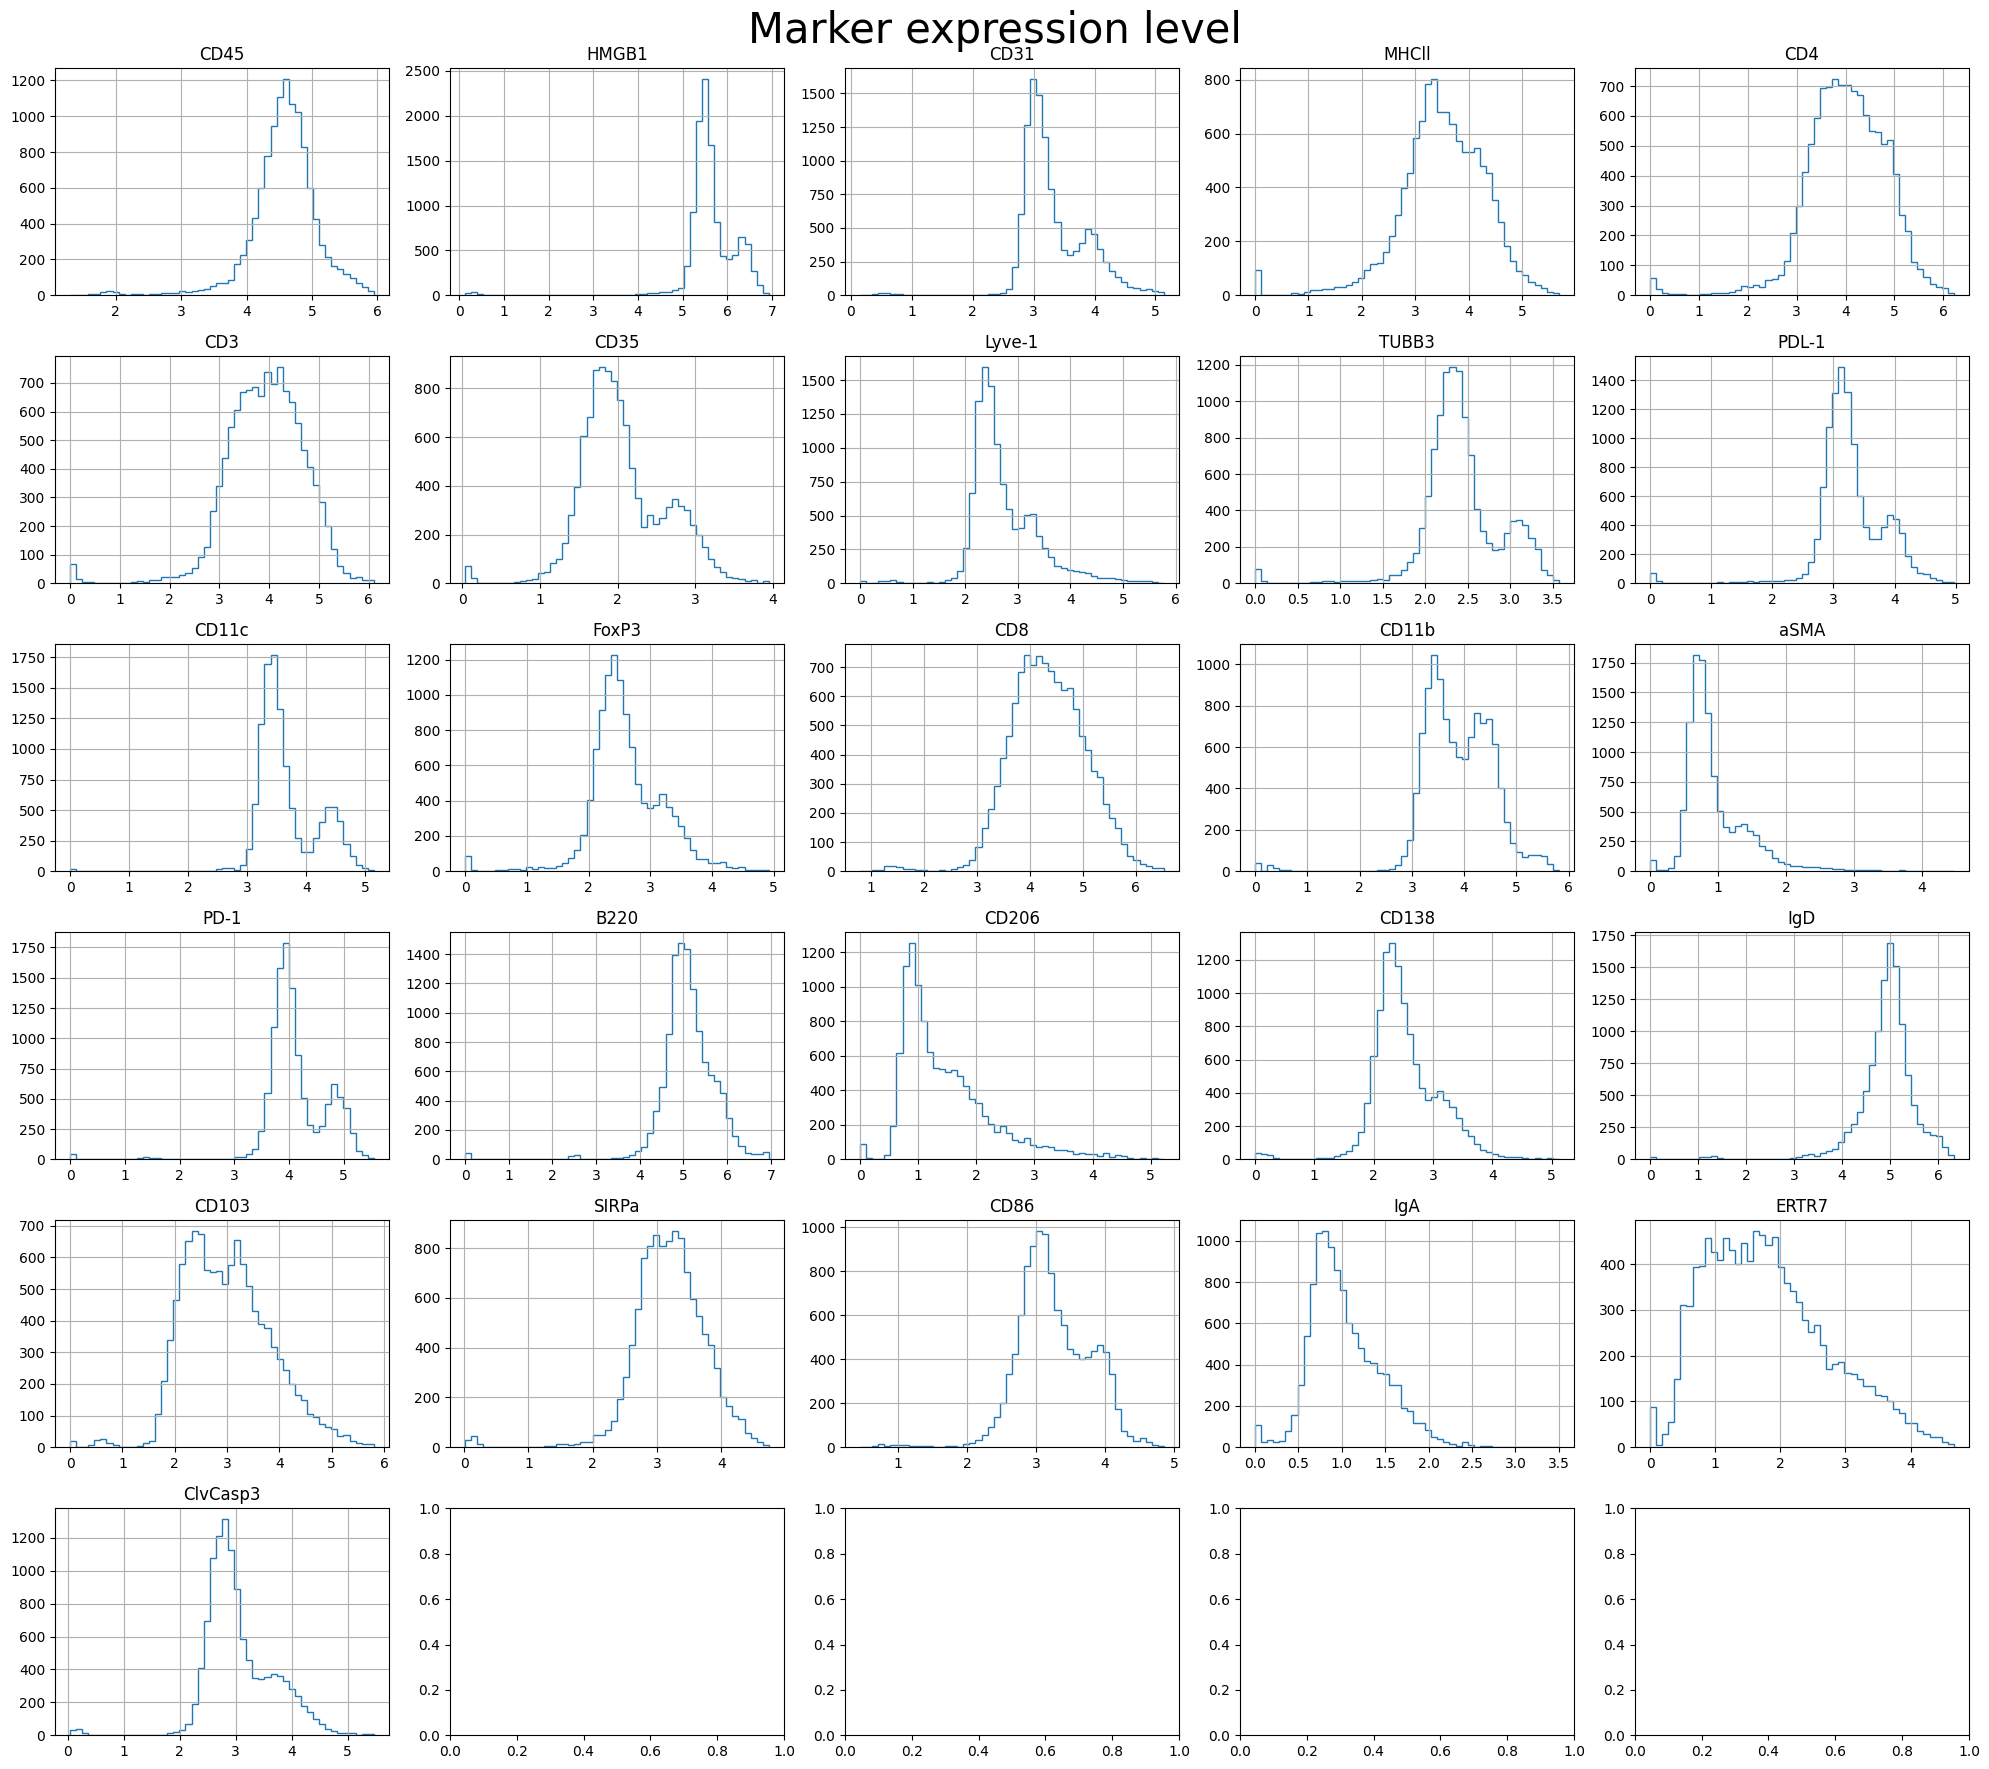

In [7]:
marker_expression(np.arcsinh(sample_data[cols]/5.0), markers=None, save=True, fname="{}/{}_marker_expression.png".format(output_path, sample_name), dpi='figure', log=False)
marker_expression(np.arcsinh(sample_data[cols]/5.0), markers=None, save=False, fname="{}/{}_marker_expression.png".format(output_path, sample_name), dpi='figure', log=False)

In [10]:
# read logic table
logic_table_name = "LogicTable"
df = pd.ExcelFile("{}/{}.xlsx".format(path, logic_table_name))
logic = pd.read_excel(df, df.sheet_names, index_col=0)

In [12]:
logic

{'LogicTable':           CD8_T  CD8_T_Act  CD4_T  CD4_T_Act  T_Reg  B_Naive  B_Act  Plasma  \
 CD45          1          1      1          1      1        1      1       1   
 HMGB1         0          0      0          0      0        0      0       0   
 CD31         -1         -1     -1         -1     -1       -1     -1      -1   
 MHCll         0          0      0          0      0        0      0       0   
 CD4          -1         -1      1          1      1       -1     -1      -1   
 CD3           1          1      1          1      1        0      0       0   
 CD35         -1         -1     -1         -1     -1       -1     -1      -1   
 Lyve-1       -1         -1     -1         -1     -1       -1     -1      -1   
 TUBB3         0          0      0          0      0        0      0       0   
 PDL-1         0          0      0          0      0        0      0       0   
 CD11c        -1         -1     -1         -1     -1       -1     -1      -1   
 FoxP3        -1         -

# Run Tribus

In [154]:
# set random seed to ensure reproducity
depth = 1
labels, scores = tribus.run_tribus(np.arcsinh(sample_data[cols]/5.0), logic, depth=depth, normalization=z_score, 
                            tuning=0, sigma=1, learning_rate=1, 
                            clustering_threshold=100, undefined_threshold=0.0005, other_threshold=0.4, random_state=42)

Global, subsetting done
 [ 500 / 500 ] 100% - 0:00:00 left 
 quantization error: 0.5785940295801937
2.3227710207303365 minutes


In [155]:
labels

,Global,final_label
0,Cancer,Cancer
1,Stromal,Stromal
2,Stromal,Stromal
3,Stromal,Stromal
4,CD4.T.cell,CD4.T.cell
...,...,...
556516,Stromal,Stromal
556517,Stromal,Stromal
556518,Cancer,Cancer
556519,Cancer,Cancer


# Visualization

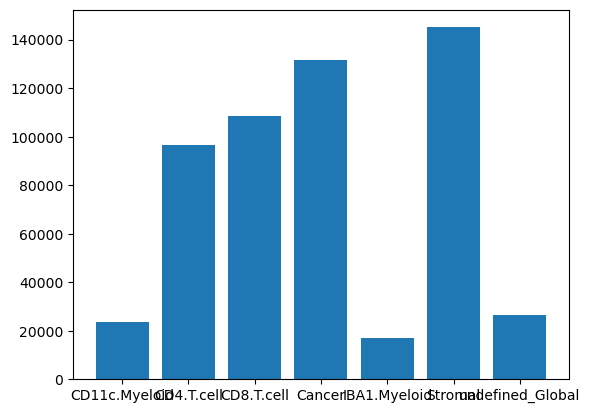

<Figure size 1600x700 with 0 Axes>

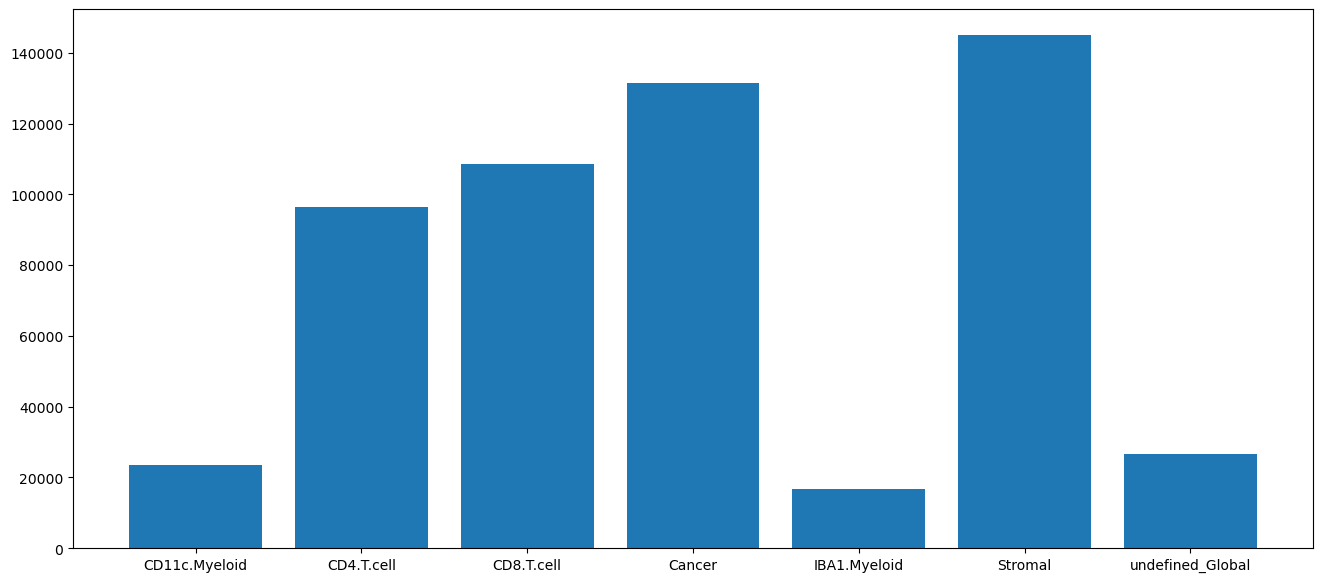

In [156]:
tribus.cell_type_distribution(labels, level="Global", save=False, fname=None, dpi="Figure")
plt.figure(figsize = (16,7))
tribus.cell_type_distribution(labels, level="final_label", save=True, fname="{}/{}_barplot.png".format(output_path, sample_name), dpi="Figure")
plt.figure(figsize = (16,7))
tribus.cell_type_distribution(labels, level="final_label", save=False, fname=None, dpi="Figure")

<Figure size 800x600 with 0 Axes>

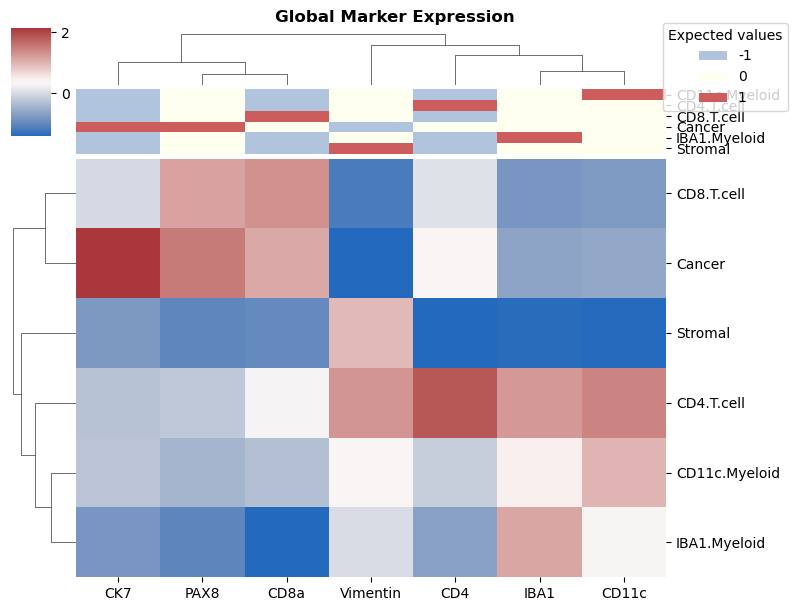

In [157]:
for i in labels.columns.values.tolist()[ : -1]: 
    heatmap_for_median_expression(sample_data, labels, logic, level=i, save=True, fname="{}/{}_heatmap.png".format(output_path, sample_name), 
                                    dpi='figure', transform=z_score, title="{} Marker Expression".format(i),
                                    c_palette=sns.color_palette(['lightsteelblue', 'ivory', 'indianred'], 3),
                                    cmap_='vlag', dendrogram_ratio_=0.1)
    
for i in labels.columns.values.tolist()[ : -1]: 
    heatmap_for_median_expression(sample_data, labels, logic, level=i, save=False, fname="{}/{}_heatmap.png".format(output_path, sample_name), 
                                    dpi='figure', transform=z_score, title="{} Marker Expression".format(i),
                                    c_palette=sns.color_palette(['lightsteelblue', 'ivory', 'indianred'], 3),
                                    cmap_='vlag', dendrogram_ratio_=0.1)

# Save the result

In [158]:
result_data = sample_data.join(labels)
labels_new = labels.join(result_data["CellID"])
labels_new.to_csv('{}/{}_{}_tribus_annotation.csv'.format(output_path, sample_name, logic_table_name))
result_data.to_csv('{}/{}_{}_raw_tribus_annotated.csv'.format(output_path, sample_name, logic_table_name))